# Chapter 13: The Walmart War Room
Build a real global LightGBM model on a **synthetic** retail panel. This is
a small mechanics lesson, not M5 data or a reproduction of its leaderboard.
We forecast one day ahead at successive dates; yesterday's observed demand
is available each morning. This differs from a fixed-origin 28-day forecast.
Learn to construct causal features, ablate information, and audit a prediction.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0, str(ROOT/'companion/src'))
from forecasting_companion.common import begin, save, plt, np
import pandas as pd
import lightgbm as lgb
rng = begin(13)

## A panel with known-in-advance promotions
A row represents one item at one store on one day. Promotion schedules are
generated in advance. Demand has shared weekday structure and item levels.
The response is continuous synthetic units to isolate the feature lesson.

In [2]:
days = np.arange(300)
rows = []
for item in range(16):
    store = item % 4
    promo = rng.binomial(1, .16, len(days))
    price = 10 + item % 3 - 2*promo
    y = 25 + 2*item + 7*np.sin(2*np.pi*days/7) + 16*promo + rng.normal(0, 3, len(days))
    rows.append(pd.DataFrame(dict(item=item, store=store, day=days, promo=promo, price=price, y=y)))
panel = pd.concat(rows, ignore_index=True).sort_values(['item', 'day'])
panel['dow'] = panel.day % 7
for lag in [1, 7, 14]:
    panel[f'lag{lag}'] = panel.groupby('item').y.shift(lag)
# Shift BEFORE rolling: y[t] must never appear in a feature used to predict y[t].
panel['mean7'] = panel.groupby('item').y.transform(lambda s: s.shift(1).rolling(7).mean())
frame = panel.dropna().copy()
check = panel.query('item == 0').set_index('day')
assert np.isclose(check.loc[20, 'mean7'], check.loc[13:19, 'y'].mean())
assert np.isclose(check.loc[20, 'lag7'], check.loc[13, 'y'])
print(frame[['item', 'day', 'y', 'lag1', 'lag7', 'mean7', 'promo']].head().round(2).to_string(index=False))

 item  day     y  lag1  lag7  mean7  promo
    0   14 34.69 33.45 28.68  29.97      1
    0   15 44.72 34.69 25.95  30.83      1
    0   16 31.18 44.72 33.37  33.51      0
    0   17 27.32 31.18 27.19  33.20      0
    0   18 19.11 27.32 26.08  33.22      0


## Rolling origins and a feature ablation
Each fold fits through day T-1 and scores the next 28 daily one-step forecasts.
The model stays fixed within the fold while observed lags update daily.
Remove promotions AND price together because price reveals the promotion.
An ablation measures predictive usefulness here, not a causal treatment effect.

model   Lags + calendar  Seasonal naive  With promotion
origin                                                 
216                4.80            6.80            2.56
244                4.91            6.76            2.64
272                4.85            6.50            2.40


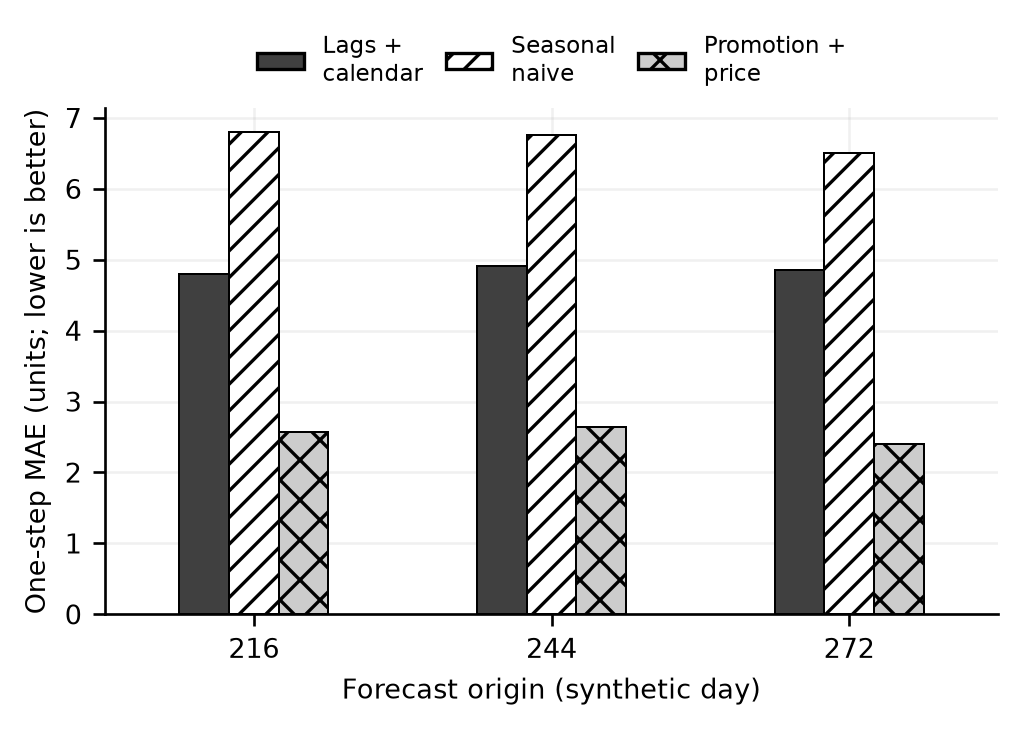

In [3]:
basic = ['item', 'store', 'dow', 'lag1', 'lag7', 'lag14', 'mean7']
full = basic + ['promo', 'price']
scores, predictions = [], []
for origin in [216, 244, 272]:
    train = frame[frame.day < origin]
    test = frame[(frame.day >= origin) & (frame.day < origin+28)].copy()
    assert train.day.max() < test.day.min()
    test['Seasonal naive'] = test.lag7
    for name, features in [('Lags + calendar', basic), ('With promotion', full)]:
        model = lgb.train({'objective': 'regression', 'num_leaves': 15,
                           'learning_rate': .07, 'seed': 13, 'num_threads': 1,
                           'verbosity': -1},
                          lgb.Dataset(train[features], label=train.y), num_boost_round=100)
        test[name] = model.predict(test[features])
    for name in ['Seasonal naive', 'Lags + calendar', 'With promotion']:
        scores.append(dict(origin=origin, model=name, mae=np.abs(test.y-test[name]).mean()))
    predictions.append(test)
scores = pd.DataFrame(scores)
print(scores.pivot(index='origin', columns='model', values='mae').round(2).to_string())
comparison = scores.pivot(index='origin', columns='model', values='mae')
fig, ax = plt.subplots(figsize=(4.3, 3.1))
comparison.plot.bar(rot=0, ax=ax, color=['.25', 'white', '.8'], edgecolor='black', legend=False)
for bars, hatch in zip(ax.containers, ['', '///', 'xx']):
    for bar in bars:
        bar.set_hatch(hatch)
ax.set(xlabel='Forecast origin (synthetic day)', ylabel='One-step MAE (units; lower is better)')
ax.set_axisbelow(True)
ax.legend(ax.containers, ['Lags +\ncalendar', 'Seasonal\nnaive', 'Promotion +\nprice'],
          loc='lower center', bbox_to_anchor=(.5, 1.02), ncol=3,
          fontsize=7, frameon=False, borderaxespad=0, columnspacing=1)
save(13, 1, 'Retail feature ablation',
     'Synthetic retail panel: three chronological folds compare seasonal naive with actual LightGBM models, with and without planned promotion and price features. Lower one-day MAE is better.',
     'Section Three: The Feature Engineering Art')

## Read one forecast and its additive explanation
LightGBM's native contribution calculation returns TreeSHAP contributions.
They add to the prediction with the expected-value column, but correlated
features can share credit. These are model explanations, not causal effects.

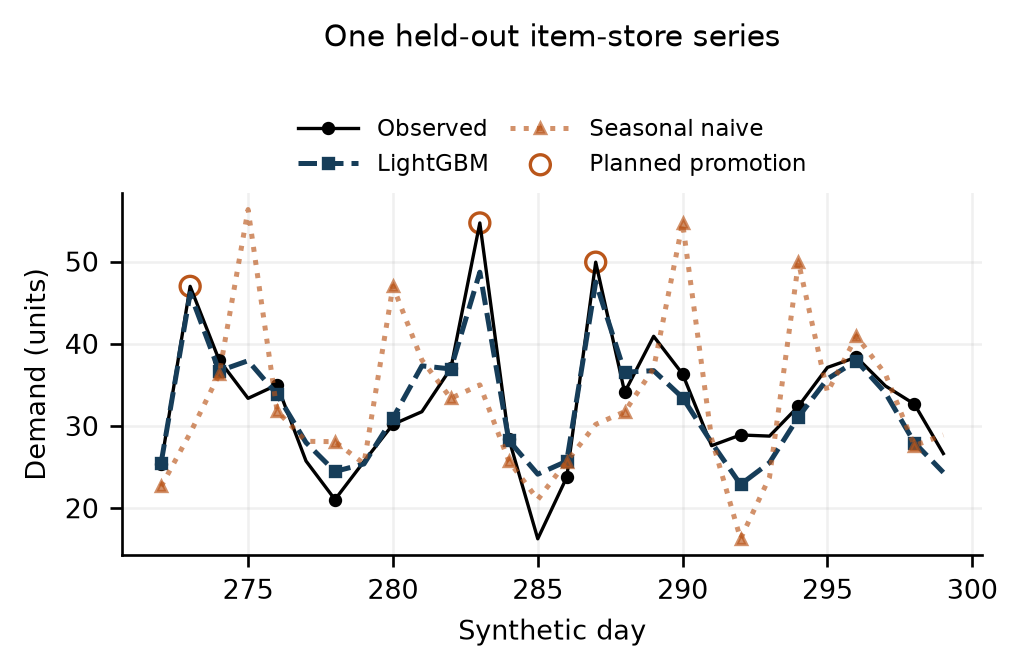

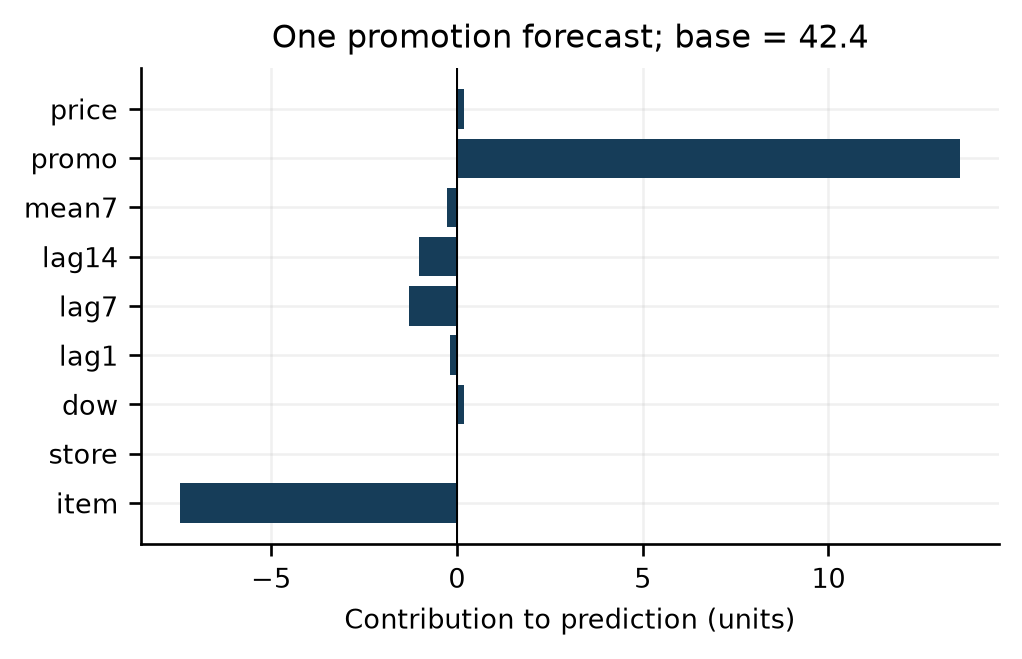

In [4]:
example = predictions[-1].query('item == 3')
fig, ax = plt.subplots()
ax.plot(example.day, example.y, label='Observed', color='black', linewidth=1)
ax.plot(example.day, example['With promotion'], label='LightGBM')
ax.plot(example.day, example['Seasonal naive'], label='Seasonal naive', alpha=.65)
ax.scatter(example.loc[example.promo == 1, 'day'], example.loc[example.promo == 1, 'y'],
           marker='o', facecolors='none', edgecolors='#ba561a', label='Planned promotion')
ax.set(xlabel='Synthetic day', ylabel='Demand (units)', title='One held-out item-store series')
ax.legend(fontsize=6)
save(13, 2, 'Retail held-out demand',
     'Synthetic item 3, last fold. Forecasts update their lag inputs after each observed day. Circled observations occur on promotions known in advance.',
     'Section Two: What the M5 Revealed', fig)
row = example[example.promo == 1].iloc[[0]]
contrib = model.predict(row[full], pred_contrib=True)[0]
assert np.isclose(contrib.sum(), model.predict(row[full])[0])
fig, ax = plt.subplots()
ax.barh(full, contrib[:-1])
ax.axvline(0, color='black', linewidth=.6)
ax.set(xlabel='Contribution to prediction (units)', title=f'One promotion forecast; base = {contrib[-1]:.1f}')
save(13, 3, 'Explain a LightGBM forecast',
     'Native TreeSHAP contributions for one synthetic promotion-day prediction. Contributions plus the base value equal the fitted prediction; attribution is not causation.',
     'Section Four: The Methods in Full', fig)

## Limitations and exercise
These units are not Walmart sales. We do not reproduce WRMSSE, the M5 hierarchy,
intermittent demand, or its uncertainty competition. Known future prices are
a deployment assumption that must be checked with the business.
Exercise: increase the horizon to seven days at a fixed origin. Which lag
features become unavailable? Implement recursive predictions or horizon-safe
direct features, and compare results without using the held-out actuals.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A panel of at least four related series with any number of numeric covariate columns. Declare the covariates to use in config `covariates` and, within them, those whose future values are genuinely known at the forecast origin in `known_in_advance` (a promotion calendar, a list price). Covariates not known in advance are lagged one period by the tool; they never enter at their own timestamp.

Minimal **format illustration**, not sufficient training data:

```csv
series_id,timestamp,target,promo,price
item-0,2021-01-01,53.8,0,10
item-0,2021-01-02,55.1,1,8
item-1,2021-01-01,41.2,0,10
```

## Explain the mechanism

Pooled trees learn shared nonlinear relationships across related item-store series. Their advantage comes from useful predictors available at the decision time. Excellent retrospective results can disappear when supposedly predictive columns were only known after the outcome.

## Work through the arithmetic

For demand values 10,12,14 on days 1–3, the day-4 three-day rolling feature is 12. A rolling mean that includes day-4 actual 20 would use [12,14,20], or 15.333, and leak the target. If base prediction 20 and SHAP contributions 3,-1,5 sum to 7, the model output is 27.

## Adapt the lesson to reader data

Replace panel construction with series_id mapped to the lesson’s entity key and a consistent time index. Preserve groupby boundaries for all lags. Include store/item fields only if actual metadata supports them; series_id alone does not magically recover that hierarchy. The lesson's folds are successive one-step forecasts with lag updates; the tool's default `strategy: direct` issues the whole horizon once at each origin (the daily example forecasts seven days from Monday). Choose the strategy that matches the decision and say which one ran.

For this chapter, settle these questions before fitting: Is the decision daily one-step replenishment or a fixed-origin horizon? Were promotions and prices known then? Are sales censored by stockouts? What defines a series?

## Interpret the actual lesson outputs

The source runs actual LightGBM and native TreeSHAP on synthetic retail data. Its 28-day folds contain successive one-day forecasts with lag updates, not a 28-day forecast issued once; the applied tool below issues a seven-day direct forecast at each origin on the same kind of daily panel. It does not reproduce M5 hierarchy, WRMSSE or Walmart data. In the shipped example the ablation shows that dropping a feature group can also lower MAE: a feature that does not help on the holdout is noise for that panel, not a law.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `series_id,timestamp,horizon,actual,seasonal_naive,prediction`.
- `summary.json`: `strategy,features,feature_groups,covariates,known_in_advance,validation,ablation,test_mae,baseline_mae,first_explanation,origins` plus method, interpretation, assumptions, not_done and status.

LightGBM on leakage-safe grouped features: lags (`lags`), shifted rolling means (`rolling`), a calendar term (day of week for daily data, month otherwise), an entity code, and the declared covariates. `strategy: direct` (default) fits one booster per horizon step, each mapping the origin's lag features plus the target date's known covariates and calendar to that step's target; `recursive` fits a one-step model and feeds its own predictions back as lags. Evaluation uses expanding origins (`origins`) against seasonal naive computed from pre-origin history, then scores the untouched final holdout once. `ablation: true` drops each feature group (calendar, lags, rolling, covariates) in turn at every origin and reports the change in MAE. Additive contributions are returned for `shap_rows` rows with an additivity check. No hyperparameter search, no quantile objective. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Removing promotion while retaining discount price may leave the same information. Ablate dependent feature groups. Check negative predictions, lag availability and error concentration in sparse series. TreeSHAP allocations among correlated features depend on the model and are not identified marketing effects.

If LightGBM is unavailable, name the skipped model and run an eligible baseline; do not relabel a substitute. If future prices are unknown, use a known schedule or scenarios. If demand is censored, separate observed sales prediction from latent demand estimation.

The applied deliverable must make these items inspectable: `results.csv` columns: `series_id,timestamp,horizon,actual,seasonal_naive,prediction`; `summary.json` keys: `strategy,features,feature_groups,covariates,known_in_advance,validation,ablation,test_mae,baseline_mae,first_explanation,origins` plus method, interpretation, assumptions, not_done and status. State which covariates were treated as known in advance; a forecast that assumes next month's price is known must say so.

## Three exercises with worked solutions

### Exercise 1

At a Monday origin, may Wednesday’s observed sales be a lag for Friday’s fixed-origin forecast?

**Worked solution.** No. They are unknown Monday. Use recursive predictions or horizon-safe direct features.

### Exercise 2

Ablation removes promo but leaves promo-discount price. What is the problem?

**Worked solution.** Price still encodes much of the promotion; the ablation does not isolate that information group.

### Exercise 3

SHAP assigns +10 to promotion. Is causal lift 10 units?

**Worked solution.** No. It explains a fitted prediction under model assumptions, not an intervention effect.

## Business-reader application

Use this request with the skill:

> Use chapter 13 to forecast retail_panel.csv one day ahead, audit every feature’s availability and compare LightGBM with seasonal-naive and a promotion/price ablation.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch13.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch13.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(13, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch13-workshop-results.csv', index=False)
_ = (workshop_output/'ch13-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: LightGBM panel model (direct multi-step) with declared covariates
Status: passed

Interpretation: direct LightGBM: final-holdout MAE 1.449 vs seasonal naive 6.089; validation origins 3. Ablation: dropping calendar changes MAE by +1.53, lags changes MAE by +0.117, rolling changes MAE by +0.439, covariates changes MAE by +1.83. Contributions explain the model, not intervention effects.

Assumptions:
  - Feature timing preserved: every feature is available at the forecast origin
  - Known-in-advance covariates are exactly known for the horizon
  - Seasonal period 7
Not done:
  - Covariates not listed in known_in_advance were lagged one period; future values of known covariates must be supplied by the reader for a live forecast
  - No hyperparameter search: fixed LightGBM settings
  - Quantile or count objectives not fitted; use chapter 17 for intervals

Evidence:
  strategy: direct
  features: <7 rows>
  feature_groups: <4 entries>
  covariates: [promo, price]
  known_in_advance: 

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Is every feature known at the forecast origin for the whole horizon, including prices and promotions?**
   A bad answer looks like this: A model fed next month's price forecasts a world where next month's price is already known.

2. **Does the ablation show which feature groups earn their place on the holdout?**
   A bad answer looks like this: A feature that does not help on unseen data is complexity paid for without return.

3. **Are the explanations read as descriptions of the model, not as causal effects?**
   A bad answer looks like this: Treating a contribution value as the lift a promotion would cause is the chapter's central warning.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).